In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Differentiation

## Single Variable

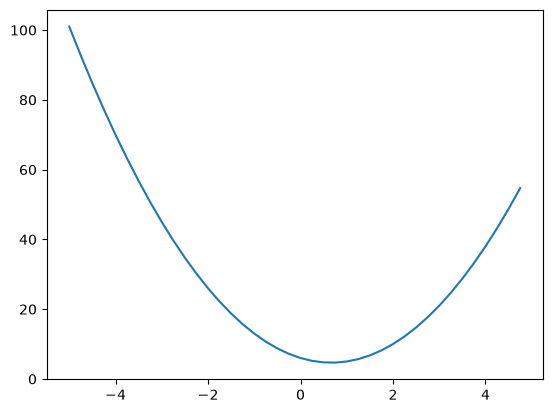

In [8]:
def f(x):
    out = 3 * x**2 - 4 * x + 6
    return out


xs = np.arange(-5, 5, 0.25)
ys = f(xs)
plt.plot(xs, ys)

In [9]:
x = 2.0
h = 0.001
(f(x + h) - f(x)) / h

8.003000000000426

In [10]:
x = -2.0
h = 0.001
(f(x + h) - f(x)) / h

-15.996999999998707

## Multi Variable

In [ ]:
%%time
h = 0.001

a = 2.0
b = -3.0
c = 10
d1 = a * b + c

# a = 2.0 + h
b = -3.0 + h
c = 10
d2 = a * b + c

(d2-d1)/h

CPU times: total: 0 ns
Wall time: 13.1 μs


1.9999999999997797

In [1]:
1+1

2

# Value

In [141]:
class Value:
    def __init__(self, data, _prev=(), _op="", label="", grad=0.0):
        self.data = data
        self._prev = list(_prev)
        self._op = _op
        self.label = label
        self.grad = grad
        self._backward = lambda: None

    def __repr__(self):
        return f"Value(data = {self.data}, _op = {self._op}, label = {self.label}, grad = {self.grad})"

    def __add__(self, other):
        t = Value(self.data + other.data, _prev=[self, other], _op="+")
        def _backward():
            self.grad += t.grad
            other.grad += t.grad
        t._backward = _backward
            
        return t

    def __mul__(self, other):
        t = Value(self.data * other.data, _prev=[self, other], _op="*")
        def _backward():
            self.grad += t.grad * other.data
            other.grad += t.grad * self.data
        t._backward = _backward
        return t
    
    def backward(self):
        self.grad = 1.0
        for n in topo(self):
            n._backward()


# a = Value(2.0)
# a.label = "a"
# b = Value(-3.0)
# b.label = "b"
# c = Value(10.0)
# c.label = "c"
# # d = a * b; d.label = 'd'
# d = a * b + c
# d.label = "d"
# d

In [47]:
a = Value(2.0)
b = Value(-3.0)
c = Value(10.0)
d = a * b + c

# def trace(root):
#     
# 
# nodes, edges = trace(d)
# assert len(nodes) == 5      # a, b, c, (a*b), d
# assert len(edges) == 4

# Plot graph

In [35]:
import os
os.environ["PATH"] += os.pathsep + r"C:\\Program Files\\Graphviz\\bin"
from graphviz import Digraph

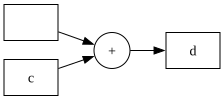

In [ ]:
root = d
g = Digraph(format="svg", graph_attr={"rankdir": "LR"})   # LR = ซ้ายไปขวา
g.node(name=str(id(root)), label=root.label, shape="record")
g.node(name=str(id(root))+root._op, label=root._op, shape="circle")
g.edge(str(id(root))+root._op, str(id(root)))

g.node(name=str(id(root._prev[0])), label=root._prev[0].label, shape="record")
g.node(name=str(id(root._prev[1])), label=root._prev[1].label, shape="record")
g.edge(str(id(root._prev[0])), str(id(root))+root._op)
g.edge(str(id(root._prev[1])), str(id(root))+root._op)

g

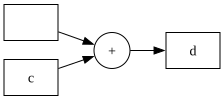

In [55]:
# Manual
def trace(root):
    g = Digraph(format="svg", graph_attr={"rankdir": "LR"})   # LR = ซ้ายไปขวา
    g.node(name=str(id(root)), label=root.label, shape="record")
    g.node(name=str(id(root))+root._op, label=root._op, shape="circle")
    g.edge(str(id(root))+root._op, str(id(root)))

    g.node(name=str(id(root._prev[0])), label=root._prev[0].label, shape="record")
    g.node(name=str(id(root._prev[1])), label=root._prev[1].label, shape="record")
    g.edge(str(id(root._prev[0])), str(id(root))+root._op)
    g.edge(str(id(root._prev[1])), str(id(root))+root._op)
    
    return g

g = trace(d)
g

## Trace

In [ ]:
import pprint


def trace(root: Value):
    nodes = set()
    edges = set()

    def f(node: Value):
        if node in nodes:
            return
        nodes.add(node)
        for n in node._prev:
            f(n)
            edges.add((n, node))

    f(root)
    return nodes, edges


def plot_graph(nodes, edges):
    g = Digraph(format="svg", graph_attr={"rankdir": "LR"})  # LR = ซ้ายไปขวา
    for n in nodes:
        # label = (
        #     n._prev[0].label + n._op + n._prev[1].label if n.label == "" else n.label
        # )
        g.node(
            name=str(id(n)),
            label=f"{{{n.label} | {n.data} | grad: {n.grad}}}",
            shape="record",
        )
        if n._op != "":
            g.node(name=str(id(n)) + n._op, label=n._op, shape="circle")
            g.edge(str(id(n)) + n._op, str(id(n)))

    for e in edges:
        l = e[0]
        r = e[1]
        g.edge(str(id(l)), str(id(r)) + r._op)

    return g

In [ ]:
def trace_no_guard(root: Value):
    nodes = set()
    edges = set()
    
    def f(node: Value):
        nodes.add(node)
        for n in node._prev:
            f(n)
            edges.add((n, node))
        
    f(root)
    return nodes, edges

def trace_with_guard(root: Value):
    nodes = set()
    edges = set()
    
    def f(node: Value):
        if node in nodes:
            return
        nodes.add(node)
        for n in node._prev:
            f(n)
            edges.add((n, node))
        
    f(root)
    return nodes, edges

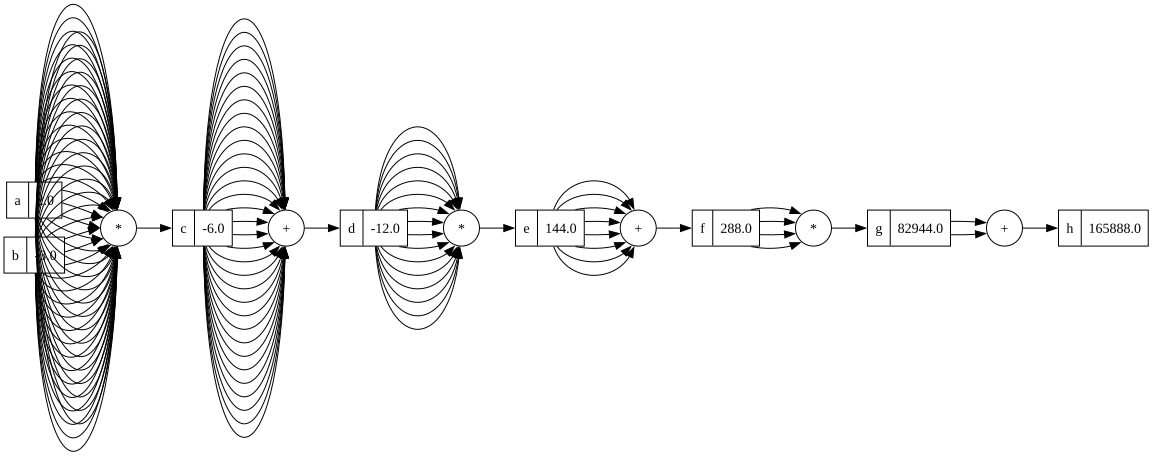

In [158]:
a = Value(2.0); a.label = "a"
b = Value(-3.0); b.label = "b"
c = a*b; c.label = "c"
d = c+c; d.label = "d"
e = d*d; e.label = "e"
f = e+e; f.label = "f"
g = f*f; g.label = "g"
h = g+g; h.label = "h"

nodes, edges = trace_no_guard(h)
g = plot_graph(nodes, edges)
g

In [156]:
%%timeit

nodes, edges = trace_no_guard(h)
# g = plot_graph(nodes, edges)
# g

13.4 μs ± 47.5 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


In [157]:
%%timeit

nodes, edges = trace_with_guard(h)
# g = plot_graph(nodes, edges)
# g

1.77 μs ± 10 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)


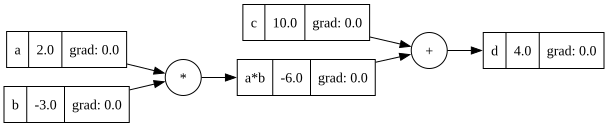

In [170]:
a = Value(2.0); a.label = "a"
b = Value(-3.0); b.label = "b"
c = Value(10.0); c.label = "c"
# d = a * b; d.label = 'd'
d = a * b + c; d.label = "d"

nodes, edges = trace(d)
# pprint.pp(nodes)
# pprint.pp(edges)
g = plot_graph(nodes, edges)
g

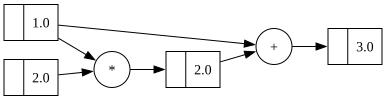

In [149]:
x = Value(1.0)
y = Value(2.0)
z = x * y + x

nodes, edges = trace(z)
g = plot_graph(nodes, edges)
g


{Value(data = 2.0, _op = ),
 Value(data = 12.0, _op = +),
 Value(data = 3.0, _op = ),
 Value(data = 6.0, _op = *)}
{(Value(data = 3.0, _op = ), Value(data = 6.0, _op = *)),
 (Value(data = 2.0, _op = ), Value(data = 6.0, _op = *)),
 (Value(data = 6.0, _op = *), Value(data = 12.0, _op = +))}


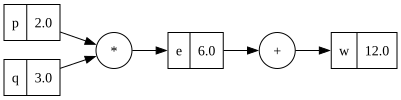

In [150]:
p = Value(2.0); p.label = 'p'
q = Value(3.0); q.label = 'q'
e = p * q; e.label = 'e'
w = e + e; w.label = 'w'

nodes, edges = trace(w)
pprint.pp(nodes)
pprint.pp(edges)
g = plot_graph(nodes, edges)
g


# Calculate gradient manually

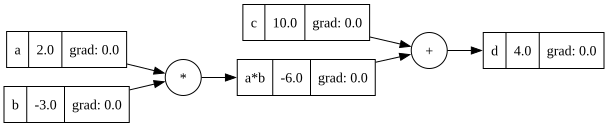

In [171]:
a = Value(2.0); a.label = "a"
b = Value(-3.0); b.label = "b"
c = Value(10.0); c.label = "c"
# d = a * b; d.label = 'd'
d = a * b + c; d.label = "d"

nodes, edges = trace(d)
# pprint.pp(nodes)
# pprint.pp(edges)
g = plot_graph(nodes, edges)
g

dd/dd = 1
dd/dc = d(e+c)/dc = dc/dc = 1
dd/de = d(e+c)/de = de/de = 1
dd/da = dd/de * de/da = 1 * d(a*b)/da = 1 * b = -3
dd/db = dd/de * de/db = 1 * d(a*b)/db = 1 * a = 2

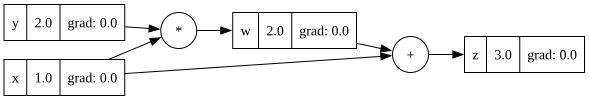

In [188]:
x = Value(1.0); x.label = "x"
y = Value(2.0); y.label = "y"
w = x * y; w.label = "w"
z = w + x; z.label = "z"

nodes, edges = trace(z)
g = plot_graph(nodes, edges)
g


In [ ]:
z.grad = 1
w.grad += z.grad
x.grad += z.grad
y.grad += w.grad * x.data
x.grad += w.grad * y.data

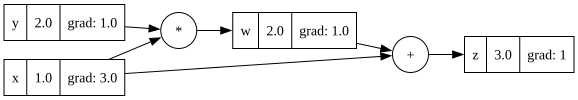

In [190]:
nodes, edges = trace(z)
g = plot_graph(nodes, edges)
g

z = x*y + x = x(y+1)
z = w + x

dz/dz = 1
dz/dw = d(w+x)/dw = dw/dw + dx/dw = 1 + dx/dw = 1 + 0 = 1, ปัญหามันอยู่ตรงนี้เพราะว่า  w มันเป็นฟังก์ชันของ x ด้วย, จากข้างล่างแล้วมันได้คือหนึ่งอ่ะ. จากข้างล่างมันคือหนึ่ง. 
dz/dx = d(x*(y+1))/dx = y+1 = 3
dz/dy = d(x*y+x)/dy = x = 1

In [181]:
h = 0.001
x = Value(1.0); x.label = "x"
y = Value(2.0); y.label = "y"
w = x * y; w.label = "w"
z = w + x; z.label = "z"

x = Value(1.0 + h)
y = Value(2.0)
w = x * y
zr = w + x
print(f"dz/dx = {(zr.data-z.data)/h}")

x = Value(1.0)
y = Value(2.0 + h)
w = x * y
zr = w + x
print(f"dy/dx = {(zr.data-z.data)/h}")

x = Value(1.0)
y = Value(2.0)
w = x * y; w.data += h
zr = w + x
print(f"dw/dx = {(zr.data-z.data)/h}")


dz/dx = 2.9999999999996696
dy/dx = 0.9999999999998899
dw/dx = 0.9999999999998899


In [182]:
h = 0.001
f = lambda x, y: x*y + x

print((f(1.0+h, 2.0) - f(1.0, 2.0)) / h)    # ควรได้ ≈ 3
print((f(1.0, 2.0+h) - f(1.0, 2.0)) / h)    # ควรได้ ≈ 1

2.9999999999996696
0.9999999999998899


{Value(data = 1.0, _op = , label = x, grad = 0.0),
 Value(data = 3.0, _op = +, label = z, grad = 0.0),
 Value(data = 9.0, _op = *, label = q, grad = 0.0),
 Value(data = 2.0, _op = , label = y, grad = 0.0),
 Value(data = 2.0, _op = *, label = w, grad = 0.0)}


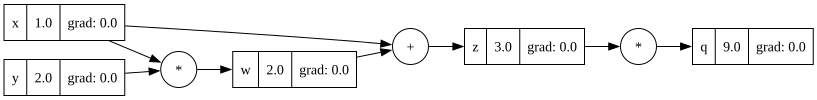

In [53]:
x = Value(1.0); x.label = "x"
y = Value(2.0); y.label  = "y"
w = x*y; w.label = "w"
z = w+x; z.label = "z"
q = z*z; q.label = "q"

nodes, edges = trace(q)
pprint.pp(nodes)
g = plot_graph(nodes, edges)
g

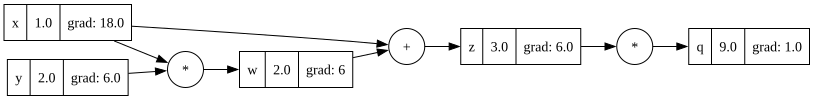

In [199]:
nodes, edges = trace(q)
g = plot_graph(nodes, edges)
g

In [193]:
q.grad = 1.0
z.grad = 2*z.data  # dq/dz = d(z^2)/dz = 2*z

In [ ]:
x.grad += z.grad
w.grad += z.grad

In [198]:
y.grad += w.grad * x.data
x.grad += w.grad * y.data

# Backward

In [28]:
# 1
x = Value(1.0); y = Value(2.0)
z = x + y
z.grad = 1.0
z._backward()
print(x.grad, y.grad)      # 1.0 1.0

1.0 1.0


In [29]:
# 2
x = Value(3.0); y = Value(4.0)
z = x * y
z.grad = 1.0
z._backward()
print(x.grad, y.grad)      # 4.0 3.0  ← สลับกัน

4.0 3.0


In [30]:
# 3  ← ทายก่อนรัน แล้วค่อยกดรัน
x = Value(3.0)
z = x + x
z.grad = 1.0
z._backward()
print(x.grad)              # นายคิดว่าได้เท่าไหร่?

2.0


In [47]:
# 4

a = Value(2.0);  a.label = "a"
b = Value(-3.0); b.label = "b"
c = Value(10.0); c.label = "c"
e = a * b;       e.label = "e"
d = e + c;       d.label = "d"

d.grad = 1.0
# แล้วเรียก _backward() ของแต่ละ node เอง — นายเป็นคนเลือกลำดับ

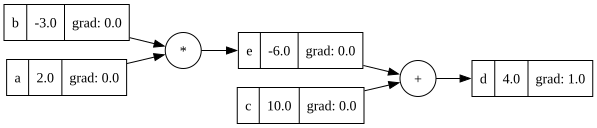

In [50]:
nodes, edges = trace(d)
g = plot_graph(nodes, edges)
g

In [45]:
d._backward()
c._backward()
e._backward()

In [49]:
c._backward()
e._backward()

## Topological Sort

In [107]:
def topo(root: Value):
    order = []
    order_set = set()

    def f(node: Value):
        if node in order_set:
            return
        for n in node._prev:
            f(n)
        order.append(node)
        order_set.add(node)

    f(root)
    return list(reversed(order))

In [108]:
def topo_no_reverse(root: Value):
    order = []
    order_set = set()

    def f(node: Value):
        if node in order_set:
            return
        for n in node._prev:
            f(n)
        order.append(node)
        order_set.add(node)

    f(root)
    return order

In [120]:
def topo_append_before_loop(root: Value):
    order = []
    order_set = set()

    def f(node: Value):
        if node in order_set:
            return
        order_set.add(node)
        order.append(node)
        for n in node._prev:
            f(n)

    f(root)
    return order

In [133]:
def topo_without_guard(root: Value):
    order = []
    order_set = set()

    def f(node: Value):
        for n in node._prev:
            f(n)
        order.append(node)
        order_set.add(node)

    f(root)
    return list(reversed(order))

In [109]:
a = Value(2.0); a.label="a"
b = Value(-3.0); b.label="b"
c = Value(10.0); c.label="c"
e = a*b; e.label="e"
d = e+c; d.label="d"

order = topo(d)                      # ตั้งชื่อฟังก์ชันเองได้
nodes, edges = trace(d)

assert set(map(id, order)) == set(map(id, nodes))   # ต้องครบทุก node ไม่ขาดไม่เกิน
assert len(order) == len(nodes)                     # ห้ามซ้ำ

pos = {id(n): i for i, n in enumerate(order)}
for child, parent in edges:
    assert pos[id(parent)] < pos[id(child)], f"{parent.label} ต้องมาก่อน {child.label}"

print("ผ่าน:", [n.label for n in order])


ผ่าน: ['d', 'c', 'e', 'b', 'a']


## Correct

In [125]:
x = Value(2.0); x.label = "x"
y = Value(3.0); y.label = "y"
p = Value(5.0); p.label = "p"
q = Value(7.0); q.label = "q"

m = x * y;  m.label = "m"      # ← node กลาง ที่ถูกใช้ซ้ำ
a = m * p;  a.label = "a"
# a = p * m;  a.label = "a"
b = m * q;  b.label = "b"
d = a * b;  d.label = "d"       # 1260

order = topo(d)                      # ตั้งชื่อฟังก์ชันเองได้
nodes, edges = trace(d)
g = plot_graph(nodes, edges)
g

assert set(map(id, order)) == set(map(id, nodes))   # ต้องครบทุก node ไม่ขาดไม่เกิน
assert len(order) == len(nodes)                     # ห้ามซ้ำ

pos = {id(n): i for i, n in enumerate(order)}
for child, parent in edges:
    assert pos[id(parent)] < pos[id(child)], f"{parent.label} ต้องมาก่อน {child.label}"

print("ผ่าน:", [n.label for n in order])


ผ่าน: ['d', 'b', 'q', 'a', 'p', 'm', 'y', 'x']


[Value(data = 1260.0, _op = *, label = d, grad = 1.0),
 Value(data = 42.0, _op = *, label = b, grad = 30.0),
 Value(data = 7.0, _op = , label = q, grad = 180.0),
 Value(data = 30.0, _op = *, label = a, grad = 42.0),
 Value(data = 5.0, _op = , label = p, grad = 252.0),
 Value(data = 6.0, _op = *, label = m, grad = 420.0),
 Value(data = 3.0, _op = , label = y, grad = 840.0),
 Value(data = 2.0, _op = , label = x, grad = 1260.0)]


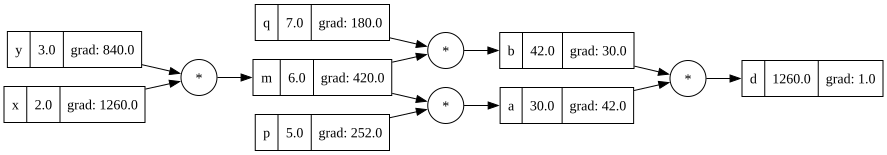

In [128]:
nodes, edges = trace(d)
g = plot_graph(nodes, edges)
pprint.pp(order)
g

In [127]:
d.grad = 1.0
for n in order:
    n._backward()

## No Reversed

In [116]:
x = Value(2.0); x.label = "x"
y = Value(3.0); y.label = "y"
p = Value(5.0); p.label = "p"
q = Value(7.0); q.label = "q"

m = x * y;  m.label = "m"      # ← node กลาง ที่ถูกใช้ซ้ำ
a = m * p;  a.label = "a"
# a = p * m;  a.label = "a"
b = m * q;  b.label = "b"
d = a * b;  d.label = "d"       # 1260

order = topo_no_reverse(d)
nodes, edges = trace(d)

[Value(data = 2.0, _op = , label = x, grad = 0.0),
 Value(data = 3.0, _op = , label = y, grad = 0.0),
 Value(data = 6.0, _op = *, label = m, grad = 0.0),
 Value(data = 5.0, _op = , label = p, grad = 0.0),
 Value(data = 30.0, _op = *, label = a, grad = 42.0),
 Value(data = 7.0, _op = , label = q, grad = 0.0),
 Value(data = 42.0, _op = *, label = b, grad = 30.0),
 Value(data = 1260.0, _op = *, label = d, grad = 1.0)]


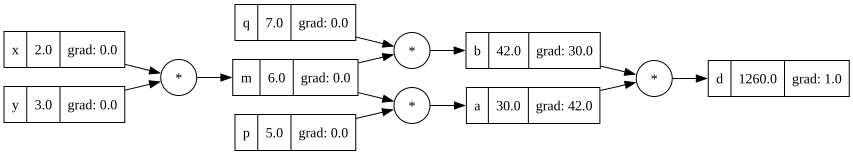

In [119]:
g = plot_graph(nodes, edges)
pprint.pp(order)
g

### Another test

In [1]:
%load_ext autoreload
%autoreload 2

from micrograd.engine import Value
from micrograd.topo import topo
from micrograd.viz import plot_graph

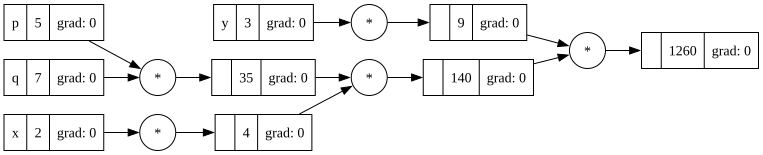

In [ ]:
x = Value(2.0); x.label = "x"
y = Value(3.0); y.label = "y"
p = Value(5.0); p.label = "p"
q = Value(7.0); q.label = "q"
d = p*q*(x*x)*(y*y)


In [3]:
d.backward()

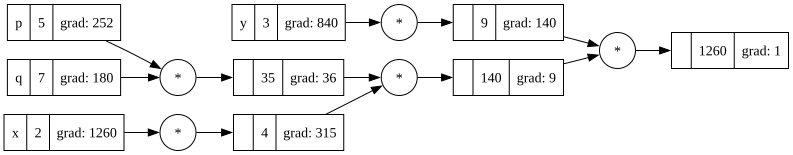

In [4]:
plot_graph(d)

In [118]:
d.grad = 1.0
for n in order:
    n._backward()

## Append Before Loop

In [121]:
x = Value(2.0); x.label = "x"
y = Value(3.0); y.label = "y"
p = Value(5.0); p.label = "p"
q = Value(7.0); q.label = "q"

m = x * y;  m.label = "m"      # ← node กลาง ที่ถูกใช้ซ้ำ
a = m * p;  a.label = "a"
# a = p * m;  a.label = "a"
b = m * q;  b.label = "b"
d = a * b;  d.label = "d"       # 1260

order = topo_append_before_loop(d)
nodes, edges = trace(d)

[Value(data = 1260.0, _op = *, label = d, grad = 1.0),
 Value(data = 30.0, _op = *, label = a, grad = 42.0),
 Value(data = 6.0, _op = *, label = m, grad = 420.0),
 Value(data = 2.0, _op = , label = x, grad = 630.0),
 Value(data = 3.0, _op = , label = y, grad = 420.0),
 Value(data = 5.0, _op = , label = p, grad = 252.0),
 Value(data = 42.0, _op = *, label = b, grad = 30.0),
 Value(data = 7.0, _op = , label = q, grad = 180.0)]


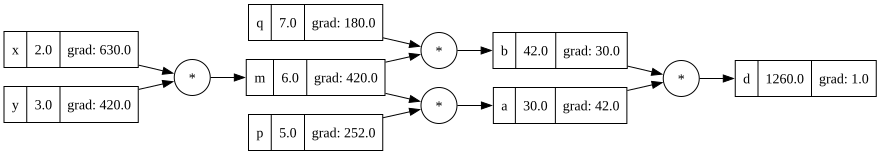

In [124]:
g = plot_graph(nodes, edges)
pprint.pp(order)
g

In [123]:
d.grad = 1.0
for n in order:
    n._backward()

## Without Guard

In [134]:
x = Value(2.0); x.label = "x"
y = Value(3.0); y.label = "y"
p = Value(5.0); p.label = "p"
q = Value(7.0); q.label = "q"

m = x * y;  m.label = "m"      # ← node กลาง ที่ถูกใช้ซ้ำ
a = m * p;  a.label = "a"
# a = p * m;  a.label = "a"
b = m * q;  b.label = "b"
d = a * b;  d.label = "d"       # 1260

order = topo_without_guard(d)
nodes, edges = trace(d)

[Value(data = 1260.0, _op = *, label = d, grad = 1.0),
 Value(data = 42.0, _op = *, label = b, grad = 30.0),
 Value(data = 7.0, _op = , label = q, grad = 180.0),
 Value(data = 6.0, _op = *, label = m, grad = 420.0),
 Value(data = 3.0, _op = , label = y, grad = 1260.0),
 Value(data = 2.0, _op = , label = x, grad = 1890.0),
 Value(data = 30.0, _op = *, label = a, grad = 42.0),
 Value(data = 5.0, _op = , label = p, grad = 252.0),
 Value(data = 6.0, _op = *, label = m, grad = 420.0),
 Value(data = 3.0, _op = , label = y, grad = 1260.0),
 Value(data = 2.0, _op = , label = x, grad = 1890.0)]


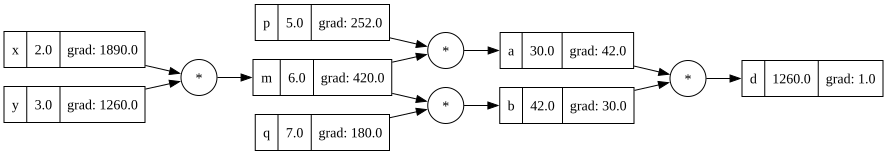

In [137]:
g = plot_graph(nodes, edges)
pprint.pp(order)
g

In [136]:
d.grad = 1.0
for n in order:
    n._backward()

## Backward()

In [151]:
x = Value(2.0); x.label = "x"
y = Value(3.0); y.label = "y"
p = Value(5.0); p.label = "p"
q = Value(7.0); q.label = "q"

m = x * y;  m.label = "m"      # ← node กลาง ที่ถูกใช้ซ้ำ
a = m * p;  a.label = "a"
b = m * q;  b.label = "b"
d = a * b;  d.label = "d"       # 1260

order = topo(d)
nodes, edges = trace(d)

[Value(data = 1260.0, _op = *, label = d, grad = 1.0),
 Value(data = 42.0, _op = *, label = b, grad = 30.0),
 Value(data = 7.0, _op = , label = q, grad = 180.0),
 Value(data = 30.0, _op = *, label = a, grad = 42.0),
 Value(data = 5.0, _op = , label = p, grad = 252.0),
 Value(data = 6.0, _op = *, label = m, grad = 420.0),
 Value(data = 3.0, _op = , label = y, grad = 840.0),
 Value(data = 2.0, _op = , label = x, grad = 1260.0)]


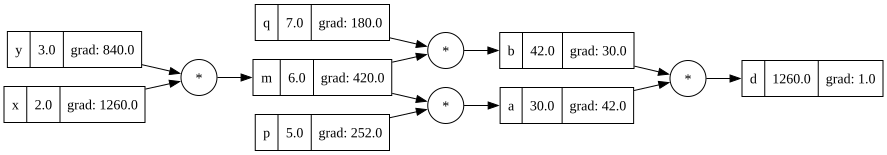

In [154]:
g = plot_graph(nodes, edges)
pprint.pp(order)
g

In [150]:
a.grad

168.0

In [153]:
d.backward()

assert d.grad == 1.0
assert a.grad == 42.0    ;  assert b.grad == 30.0
assert m.grad == 420
assert p.grad == 252   ;  assert q.grad == 180
assert x.grad == 1260  ;  assert y.grad == 840


# Python

## Closure

In [ ]:
def make_logger(prefix):
    count = 0
    def log(msg):
        nonlocal count
        count += 1
        print(f"[{prefix}#{count}] {msg}")
    return log            # คืนฟังก์ชัน ไม่ได้เรียกมัน

warn = make_logger("WARN")
info = make_logger("INFO")

In [208]:
warn("warn")
info("info")

[WARN#6] warn
[INFO#3] info


In [ ]:
warn.__code__.co_freevars

('count', 'prefix')

In [212]:
warn.__closure__

(<cell at 0x00000267F4EEC430: int object at 0x00007FFAA37A5448>,
 <cell at 0x00000267F4EECDC0: str object at 0x00000267EF54E4F0>)

## Function in Function

In [17]:
class Button:
    def __init__(self, label):
        self.label = label
        self.on_click = lambda: None       # ค่าเริ่มต้น: ฟังก์ชันที่ไม่ทำอะไร

def wire(button, stats):
    def handler():                          # ← นิยามฟังก์ชันข้างใน ธรรมดาเลย
        stats["clicks"] += 1
        print(f"  {button.label} ถูกกด {stats['clicks']} ครั้ง")
    button.on_click = handler               # ← แปะติด object ไม่มีวงเล็บ!

ok = Button("ok")
stats = {"clicks": 0}
stats["clicks"] = 0
wire(ok, stats)


In [19]:
ok.on_click()

  ok ถูกกด 2 ครั้ง


In [14]:
ok.on_click()